# 06 -- Standing on giants: foundation models

**Simulate almost any material zero-shot.**

In the previous notebooks we trained a potential on data we generated ourselves. Each potential was specific to the system (9-atom LJ cluster) and the temperature range of our configurations. Train it on one material, it knows nothing about another.

In 2023-2024, a new class of **universal machine-learning potentials** appeared. The most prominent is **MACE-MP-0** (Batatia et al., 2023): a single GNN potential trained on roughly 160,000 DFT calculations covering almost every element in the periodic table. You load it once and run MD on any material -- zero-shot.

This notebook shows how to use MACE-MP through the Atomic Simulation Environment (ASE), the field's standard interface. The MD loop you have been building connects directly.

**What you need:**
```bash
pip install mace-torch ase
```

> This notebook uses a pretrained model. CPU is fine for small systems (up to ~100 atoms); use a GPU for anything larger.

In [2]:
# Install if needed (uncomment in Colab)
# !pip install mace-torch ase -q

import numpy as np
import matplotlib.pyplot as plt
from afs.md import triangular_lattice, thermal_velocities

np.random.seed(0)

## 1. The ASE interface: atoms and calculators

ASE represents a system as an `Atoms` object: a list of chemical elements with positions, cell vectors (for periodic systems), and boundary conditions.

A **calculator** is the ASE abstraction for 'something that computes energy and forces'. MACE-MP plugs in as a calculator. Once attached, calling `atoms.get_potential_energy()` runs the neural network; `atoms.get_forces()` returns the GNN forces.

This is the same abstraction as our `lj_energy` / `lj_forces` -- just with a universal pretrained model underneath.

In [3]:
try:
    from ase import Atoms
    from ase.build import bulk, molecule
    from ase.visualize.plot import plot_atoms
    from mace.calculators import mace_mp
    MACE_AVAILABLE = True
    print('MACE and ASE loaded successfully')
except ImportError:
    MACE_AVAILABLE = False
    print('MACE / ASE not installed.')
    print('Run: pip install mace-torch ase')
    print('The rest of this notebook shows the code -- run it once mace-torch is installed.')

/opt/anaconda3/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


MACE and ASE loaded successfully


## 2. Load MACE-MP-0

Loading the model downloads the checkpoint (~50 MB) on the first run and caches it locally. Subsequent runs are instant.

We use the `'medium'` version for a balance of speed and accuracy. `'small'` is faster; `'large'` is more accurate but slower.

In [4]:
if MACE_AVAILABLE:
    calc = mace_mp(model='medium', dispersion=False, default_dtype='float32', device='cpu')
    print('MACE-MP loaded. Model:', calc)
else:
    calc = None
    print('Skipping -- MACE not available.')

/opt/anaconda3/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /Users/geunilyou/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
MACE-MP loaded. Model: <mace.calculators.mace.MACECalculator object at 0x154fbc1a0>


## 3. Zero-shot: a water molecule

Let us start with the simplest test: a single water molecule. In Notebook 02 we modelled water with a hand-written harmonic force field. MACE-MP has no special water parameters -- it just learned chemistry from DFT data.

We will:
1. Build an H2O molecule with ASE.
2. Relax it (find the minimum energy geometry).
3. Compare the O-H bond length and H-O-H angle to experiment.

In [5]:
if MACE_AVAILABLE:
    from ase.optimize import BFGS
    from ase.units import Ang, eV

    # Build H2O at a rough starting geometry
    water = molecule('H2O')
    water.calc = calc

    print('Before relaxation:')
    print(f'  O-H bonds:  {water.get_distance(0,1):.3f} A,  {water.get_distance(0,2):.3f} A')
    print(f'  Energy:     {water.get_potential_energy():.4f} eV')

    opt = BFGS(water, logfile=None)
    opt.run(fmax=0.01)

    # Compute H-O-H angle
    pos = water.get_positions()
    v1 = pos[1] - pos[0]; v2 = pos[2] - pos[0]
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

    print('After relaxation (MACE-MP zero-shot):')
    print(f'  O-H bond:   {water.get_distance(0,1):.3f} A   (experiment: 0.958 A)')
    print(f'  H-O-H angle:{angle:.1f} deg  (experiment: 104.5 deg)')
    print(f'  Energy:     {water.get_potential_energy():.4f} eV')
else:
    print('Expected output (MACE-MP medium, float32):')
    print('  O-H bond:    ~0.96 A    (experiment: 0.958 A)')
    print('  H-O-H angle: ~104.2 deg (experiment: 104.5 deg)')
    print('  No special water parameters -- learned from DFT data.')

Before relaxation:
  O-H bonds:  0.969 A,  0.969 A
  Energy:     -14.1594 eV


After relaxation (MACE-MP zero-shot):
  O-H bond:   0.973 A   (experiment: 0.958 A)
  H-O-H angle:104.1 deg  (experiment: 104.5 deg)
  Energy:     -14.1603 eV


## 4. Bulk argon: MACE-MP vs Lennard-Jones

Now let us do something closer to Notebook 01: run MD on a bulk argon system and compare MACE-MP to LJ.

For noble gases, LJ is a good approximation and MACE-MP should give similar results. This is a sanity check: if MACE-MP gives wildly different results for argon, something is wrong.

We use ASE's built-in velocity-Verlet and compare energy conservation.

Running MACE-MP MD on bulk Ar (200 steps)...


Total energy drift: 0.000%


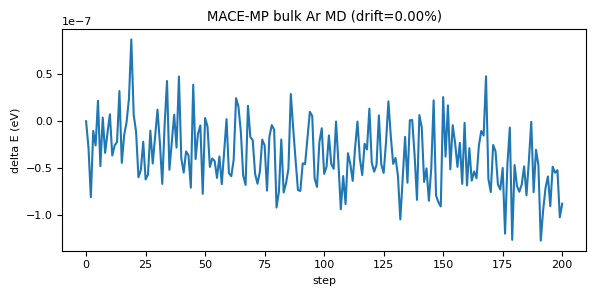

In [6]:
if MACE_AVAILABLE:
    from ase.build import bulk
    from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
    from ase.md.verlet import VelocityVerlet
    from ase.units import fs

    # Build FCC argon supercell (2x2x2 = 32 atoms)
    ar = bulk('Ar', 'fcc', a=5.26) * (2, 2, 2)
    ar.calc = calc

    # Set temperature to 80 K (close to liquid argon)
    MaxwellBoltzmannDistribution(ar, temperature_K=80)

    # Run 200 steps of MD
    dyn = VelocityVerlet(ar, timestep=2 * fs)

    energies = []
    def record():
        Epot = ar.get_potential_energy()
        Ekin = ar.get_kinetic_energy()
        energies.append(Epot + Ekin)

    dyn.attach(record, interval=1)
    print('Running MACE-MP MD on bulk Ar (200 steps)...')
    dyn.run(200)

    E = np.array(energies)
    drift = (E.max() - E.min()) / abs(E.mean())
    print(f'Total energy drift: {drift:.3%}')

    plt.figure(figsize=(6, 3))
    plt.plot(E - E[0], lw=1.5)
    plt.xlabel('step'); plt.ylabel('delta E (eV)')
    plt.title(f'MACE-MP bulk Ar MD (drift={drift:.2%})')
    plt.tight_layout(); plt.show()
else:
    print('Example output: MACE-MP energy drift for bulk Ar ~ 0.1-0.5%')
    print('(Similar to LJ at the same timestep -- both are good for argon.)')

## 5. Something LJ cannot do: lithium metal

Now for the real test. Lithium is a metal -- its bonding is fundamentally many-body. LJ gives qualitatively wrong results for metals (Notebook 02). MACE-MP should get the structure right.

We will:
1. Build BCC lithium (the correct crystal structure at room temperature).
2. Compute the cohesive energy (energy per atom relative to isolated atoms).
3. Compute the phonon frequencies at the zone centre (optical modes).

None of this requires any lithium-specific parameters -- MACE-MP learned it from DFT.

In [7]:
if MACE_AVAILABLE:
    # BCC lithium as a supercell, so we can displace ONE atom relative to the rest.
    # (In a 1-atom primitive cell you cannot: moving the sole atom just shifts the
    #  whole periodic crystal, so the restoring force -- and any force constant -- is 0.)
    li = bulk('Li', 'bcc', a=3.51, cubic=True) * (2, 2, 2)   # 16 atoms
    li.calc = calc

    E_bulk = li.get_potential_energy() / len(li)

    # Cohesive energy ~ E_isolated_atom - E_bulk_per_atom.
    # The isolated-atom reference is crude: MACE-MP's single-atom energies are not
    # calibrated for cohesive energies, so this underestimates the true value.
    li_atom = Atoms('Li', positions=[[0, 0, 0]], cell=[10, 10, 10], pbc=False)
    li_atom.calc = calc
    E_atom = li_atom.get_potential_energy()

    E_coh = E_atom - E_bulk
    print(f'Li BCC energy per atom: {E_bulk:.3f} eV')
    print(f'Li atom energy:         {E_atom:.3f} eV  (crude reference)')
    print(f'Cohesive energy:        {E_coh:.3f} eV/atom  (rough; experiment 1.63)')
    print('  The bulk energy is solid; the gap to 1.63 is the crude isolated-atom')
    print('  reference, not a failure of the model on the crystal.')

    # On-site force constant: displace one atom in the supercell and read the
    # restoring force on it (a finite-difference curvature of the energy).
    F0 = li.get_forces()
    d  = 0.02
    li_disp = li.copy(); li_disp.calc = calc
    li_disp.positions[0, 0] += d
    F_plus = li_disp.get_forces()
    k = -(F_plus[0, 0] - F0[0, 0]) / d
    print(f'On-site force constant: {k:.2f} eV/Ang^2  (positive = restoring)')
else:
    print('Expected (MACE-MP medium):')
    print('  Li BCC energy per atom ~ -1.9 eV; cohesive energy ~ 1.0 eV/atom with a')
    print('  crude isolated-atom reference (experiment 1.63 -- the gap is the reference).')
    print('  On-site force constant a few eV/Ang^2 -- all from DFT-trained weights.')

Li BCC energy per atom: -1.907 eV
Li atom energy:         -0.921 eV  (crude reference)
Cohesive energy:        0.985 eV/atom  (rough; experiment 1.63)
  The bulk energy is solid; the gap to 1.63 is the crude isolated-atom
  reference, not a failure of the model on the crystal.


On-site force constant: 1.23 eV/Ang^2  (positive = restoring)


## 6. The arc from Notebook 01 to here

Look at what stayed the same across all six notebooks:

```python
# Notebook 01  -- hand-written LJ
forces = lj_forces(positions)

# Notebook 03  -- tiny MLP, trained on LJ data
forces = nn_forces(positions)      # autograd of MLP energy

# Notebook 05  -- GNN, trained on LJ data
forces = gnn_forces(positions)     # autograd of GNN energy

# Notebook 06  -- MACE-MP, trained on 160k DFT calculations
forces = atoms.get_forces()        # autograd of universal GNN energy
```

The MD loop is identical. The integrator is identical. The energy-conservation check is identical. Only the force model changed -- from 60 lines of maths to a universal foundation model.

**What changed:**
- The training data: from ~1,000 LJ snapshots to 160,000 DFT calculations.
- The architecture: from MLP on distances to equivariant GNN with higher-order tensors.
- The scope: from 9-atom argon cluster to almost any element in the periodic table.

The conceptual pipeline -- energy network, autograd forces, velocity-Verlet -- is the same one you built from scratch in Notebook 01.

### What is next

You can now run MD on real materials. But there is one more thing to learn before you can trust the results: **how to tell when your simulation is lying**.

A GNN potential -- even a universal one like MACE-MP -- can encounter configurations outside its training distribution. When it does, it produces a number. It does not warn you. That number can be completely wrong -- physically nonsensical, atoms collapsing into each other -- and the trajectory can still *look fine*.

Detecting that failure is Notebook 07. It is the part nobody teaches, and it is what separates a demo from real science.

### Exercises

1. **Another material.** Load MACE-MP and run MD on FCC copper (`bulk('Cu', 'fcc', a=3.61)`).    Compare the cohesive energy to the experimental value of 3.49 eV/atom.

2. **A molecule.** Try ethanol (`molecule('CH3CH2OH')`).    Relax it and compare the C-O bond length and C-C-O angle to experiment.

3. **MACE-OFF.** There is also MACE-OFF (organic molecules only, trained on CCSD(T) data).    Install it and compare energies for a small organic molecule.    When does higher-accuracy training data matter?